# Gaussian Mixture Model with EM Algorithm and Naive Bayes Classifier

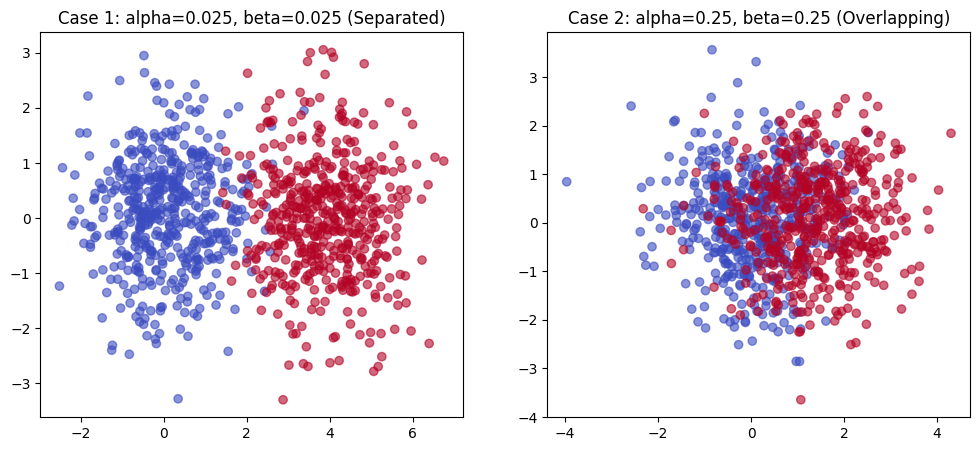

In [ ]:
import jax
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt

def generate_data(key, n_samples, mu1, mu2, cov1, cov2):
    key1, key2 = random.split(key)
    X1 = random.multivariate_normal(key1, mu1, cov1, (n_samples,))
    X2 = random.multivariate_normal(key2, mu2, cov2, (n_samples,))
    X = jnp.vstack([X1, X2])
    y = jnp.hstack([jnp.zeros(n_samples), jnp.ones(n_samples)])
    return X, y

key = random.PRNGKey(42)
key, subkey1, subkey2 = random.split(key, 3)

# Case 1: alpha = 0.025, beta = 0.025
mu1_case1 = jnp.array([0., 0.])
mu2_case1 = jnp.array([3.92, 0.])

X_case1, y_case1 = generate_data(subkey1, 500, mu1_case1, mu2_case1, cov_case1, cov_case1)

# Case 2: alpha = 0.25, beta = 0.25
mu1_case2 = jnp.array([0., 0.])
mu2_case2 = jnp.array([1.348, 0.])
cov_case2 = jnp.array([[1., 0.], [0., 1.]])

X_case2, y_case2 = generate_data(subkey2, 500, mu1_case2, mu2_case2, cov_case2, cov_case2)

# Plotting the data
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_case1[:, 0], X_case1[:, 1], c=y_case1, cmap='coolwarm', alpha=0.6)
axes[0].set_title('Case 1: alpha=0.025, beta=0.025 (Separated)')
axes[1].scatter(X_case2[:, 0], X_case2[:, 1], c=y_case2, cmap='coolwarm', alpha=0.6)
axes[1].set_title('Case 2: alpha=0.25, beta=0.25 (Overlapping)')
plt.show()

In [6]:
from jax.scipy.stats import multivariate_normal

class GaussianMixtureEM:
    def __init__(self, key, n_components=2, n_iters=1000, tol=1e-6):
        self.n_components = n_components
        self.n_iters = n_iters
        self.tol = tol
        self.key = key
        
    def fit(self, X):
        n_samples, n_features = X.shape
        self.weights = jnp.ones(self.n_components) / self.n_components
        
        # Initialize means randomly
        self.key, subkey = random.split(self.key)
        random_indices = random.choice(subkey, n_samples, shape=(self.n_components,), replace=False)
        self.means = X[random_indices]
        
        # Initialize covariances spherically
        cov_init = jnp.cov(X, rowvar=False)
        self.covs = jnp.array([cov_init for _ in range(self.n_components)])
        
        log_likelihoods = []
        
        for i in range(self.n_iters):
            # E-step
            resps = jnp.stack([
                self.weights[k] * multivariate_normal.pdf(X, self.means[k], self.covs[k])
                for k in range(self.n_components)
            ], axis=1)
            
            sum_resps = resps.sum(axis=1, keepdims=True)
            resps = resps / sum_resps
            
            # M-step
            eff_n = resps.sum(axis=0)
            self.weights = eff_n / n_samples
            
            new_means = []
            new_covs = []
            for k in range(self.n_components):
                mean_k = jnp.sum(resps[:, k:k+1] * X, axis=0) / eff_n[k]
                new_means.append(mean_k)
                
                diff = X - mean_k
                cov_k = jnp.dot(resps[:, k] * diff.T, diff) / eff_n[k]
                cov_k += jnp.eye(n_features) * 1e-6
                new_covs.append(cov_k)
                
            self.means = jnp.stack(new_means)
            self.covs = jnp.stack(new_covs)
            
            # Log Likelihood check
            ll = jnp.sum(jnp.log(sum_resps))
            log_likelihoods.append(ll)
            if i > 0 and (ll - log_likelihoods[-2] < self.tol):
                break
                
    def predict(self, X):
        resps = jnp.stack([
            self.weights[k] * multivariate_normal.pdf(X, self.means[k], self.covs[k])
            for k in range(self.n_components)
        ], axis=1)
        return jnp.argmax(resps, axis=1)

class GaussianNB:
    def fit(self, X, y):
        self.classes = jnp.unique(y)
        self.means = jnp.array([jnp.mean(X[y == c], axis=0) for c in self.classes])
        self.vars = jnp.array([jnp.var(X[y == c], axis=0) + 1e-9 for c in self.classes])
        self.priors = jnp.array([jnp.mean(y == c) for c in self.classes])
        
    def predict(self, X):
        def log_prob(x, mean, var):
            return -0.5 * jnp.sum(jnp.log(2. * jnp.pi * var) + ((x - mean) ** 2) / var, axis=1)
            
        log_probs = jnp.stack([
            jnp.log(self.priors[i]) + log_prob(X, self.means[i], self.vars[i])
            for i in range(len(self.classes))
        ], axis=1)
        
        return jnp.argmax(log_probs, axis=1)

def evaluate_models(key, X, y, title):
    # EM Model
    em_model = GaussianMixtureEM(key, n_components=2)
    em_model.fit(X)
    em_preds = em_model.predict(X)
    
    # Map clusters
    if jnp.mean(em_preds == y) < 0.5:
        em_preds = 1 - em_preds
    em_acc = jnp.mean(em_preds == y)
    
    # Naive Bayes Model
    nb_model = GaussianNB()
    nb_model.fit(X, y)
    nb_preds = nb_model.predict(X)
    nb_acc = jnp.mean(nb_preds == y)
    
    print(f"--- {title} ---")
    print(f"EM Accuracy: {em_acc:.4f} (Error rate: {1-em_acc:.4f})")
    print(f"Naive Bayes Accuracy: {nb_acc:.4f} (Error rate: {1-nb_acc:.4f})")
    print()

key, *subkeys = random.split(key, 3)
evaluate_models(subkeys[0], X_case1, y_case1, "Case 1: Alpha 0.025, Beta 0.025")
evaluate_models(subkeys[1], X_case2, y_case2, "Case 2: Alpha 0.25, Beta 0.25")

--- Case 1: Alpha 0.025, Beta 0.025 ---
EM Accuracy: 0.9740 (Error rate: 0.0260)
Naive Bayes Accuracy: 0.9790 (Error rate: 0.0210)

--- Case 2: Alpha 0.25, Beta 0.25 ---
EM Accuracy: 0.5060 (Error rate: 0.4940)
Naive Bayes Accuracy: 0.7590 (Error rate: 0.2410)

